<a href="https://colab.research.google.com/github/Likma55/budget-tracker-analysis/blob/main/budget_tracker.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Personal Budget Tracker & Analysis
**Author:** Malik Musah  
**Tools:** Python, Pandas, Matplotlib  
**Date:** 2024

## Project overview
This notebook analyses 4 months of personal transaction data (Jan–Apr 2024).

The goal is to understand spending patterns, track savings rate over time and identify which expense categories consume the most income.

This project combines my background in accounting and finance with
Python data analysis skills.

## 1. Setup & data loading
I started by uploading the transactions CSV file and loading it into a Pandas DataFrame. I also parse the date column so I can do
time-based analysis later.

In [11]:
# Import required libraries
from google.colab import files
import pandas as pd

# Upload the CSV file from local machine
uploaded = files.upload()

# Load into a DataFrame, parsing dates automatically
df = pd.read_csv('transactions.csv', parse_dates=['date'])

# Quick sanity check for shape and first few rows
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Saving transactions.csv to transactions (1).csv
Dataset loaded: 58 rows, 5 columns


,date,description,category,type,amount
0,2024-01-03,Salary,Income,income,2500.0
1,2024-01-05,Rent payment,Housing,expense,750.0
2,2024-01-06,Grocery shopping,Food,expense,85.4
3,2024-01-08,Electric bill,Utilities,expense,62.0
4,2024-01-10,Bus pass,Transport,expense,45.0


## 2. Data exploration
Before any analysis, I need to inspect the data types, check for missing values and confirm the categories are consistent. This is standard practice in any data workflow as you never assume the data is clean.

In [12]:
# Check column data types
print("Column types:")
print(df.dtypes)

# Check for missing values — important before any aggregation
print("\nMissing values per column:")
print(df.isnull().sum())

# Confirm what categories exist in the dataset
print("\nUnique categories:", df['category'].unique())
print("Transaction types:", df['type'].unique())

Column types:
date           datetime64[ns]
description            object
category               object
type                   object
amount                float64
dtype: object

Missing values per column:
date           0
description    0
category       0
type           0
amount         0
dtype: int64

Unique categories: ['Income' 'Housing' 'Food' 'Utilities' 'Transport' 'Entertainment'
 'Health' 'Shopping' 'Education']
Transaction types: ['income' 'expense']


## 3. Feature engineering
I then add a 'month' column derived from the date field. This allows me
to group transactions by month for trend analysis which is a common step
in time-series financial reporting.

In [13]:
# Extract month label (e.g. 'Jan 2024') for readable chart axes
df['month'] = df['date'].dt.strftime('%b %Y')

# Extract month period for correct chronological sorting
df['month_num'] = df['date'].dt.to_period('M')

print("Feature engineering complete. Sample:")
df[['date', 'month', 'month_num']].head(5)

Feature engineering complete. Sample:


,date,month,month_num
0,2024-01-03,Jan 2024,2024-01
1,2024-01-05,Jan 2024,2024-01
2,2024-01-06,Jan 2024,2024-01
3,2024-01-08,Jan 2024,2024-01
4,2024-01-10,Jan 2024,2024-01


## 4. Summary statistics
I splited the data into income and expenses, then calculate three
key personal finance metrics: total income, total expenses, and
savings rate. Savings rate = (net savings / total income) × 100.

In [14]:
# Split into income and expense subsets
income_df = df[df['type'] == 'income']
expense_df = df[df['type'] == 'expense']

# Calculate headline financial metrics
total_income = income_df['amount'].sum()
total_expenses = expense_df['amount'].sum()
net_savings = total_income - total_expenses
savings_rate = (net_savings / total_income) * 100

print(f"Total Income:    £{total_income:,.2f}")
print(f"Total Expenses:  £{total_expenses:,.2f}")
print(f"Net Savings:     £{net_savings:,.2f}")
print(f"Savings Rate:    {savings_rate:.1f}%")

Total Income:    £11,300.00
Total Expenses:  £5,238.18
Net Savings:     £6,061.82
Savings Rate:    53.6%


## 5. Spending breakdown by category
I grouped expenses by category to identify where most money is going.
This is similar to a cost centre analysis in management accounting.

In [15]:
# Group expenses by category and sort descending
category_totals = (
    expense_df.groupby('category')['amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
category_totals.columns = ['Category', 'Total Spent (£)']

# Add percentage column to show proportion of total spending
category_totals['% of Expenses'] = (
    category_totals['Total Spent (£)'] / total_expenses * 100
).round(1)

print(category_totals.to_string(index=False))

     Category  Total Spent (£)  % of Expenses
      Housing          3000.00           57.3
         Food          1110.20           21.2
    Utilities           435.00            8.3
    Transport           240.00            4.6
       Health           140.00            2.7
     Shopping           125.00            2.4
    Education           112.00            2.1
Entertainment            75.98            1.5


## 6. Monthly trend analysis
I pivoted the data to compare income, expenses, and savings month by month.
This reveals whether spending is increasing or decreasing over time.

In [16]:
# Pivot to get income and expenses as separate columns per month
monthly = df.groupby(['month_num', 'type'])['amount'].sum().unstack(fill_value=0)
monthly.columns = ['Expenses', 'Income']

# Derive savings and savings rate from the pivoted data
monthly['Savings'] = monthly['Income'] - monthly['Expenses']
monthly['Savings Rate %'] = (monthly['Savings'] / monthly['Income'] * 100).round(1)

# Convert period index to readable string for display
monthly.index = monthly.index.strftime('%b %Y')

print(monthly.to_string())

           Expenses  Income  Savings  Savings Rate %
month_num                                           
Jan 2024    1291.19  2800.0  1508.81            53.9
Feb 2024    1292.30  2700.0  1407.70            52.1
Mar 2024    1337.19  2950.0  1612.81            54.7
Apr 2024    1317.50  2850.0  1532.50            53.8


## 7. Visualisations
I needed to produce two charts:
1. A horizontal bar chart showing total spending per category
2. A line chart showing monthly income, expenses, and savings trends

Both charts will be saved as PNG files for use in the project README.

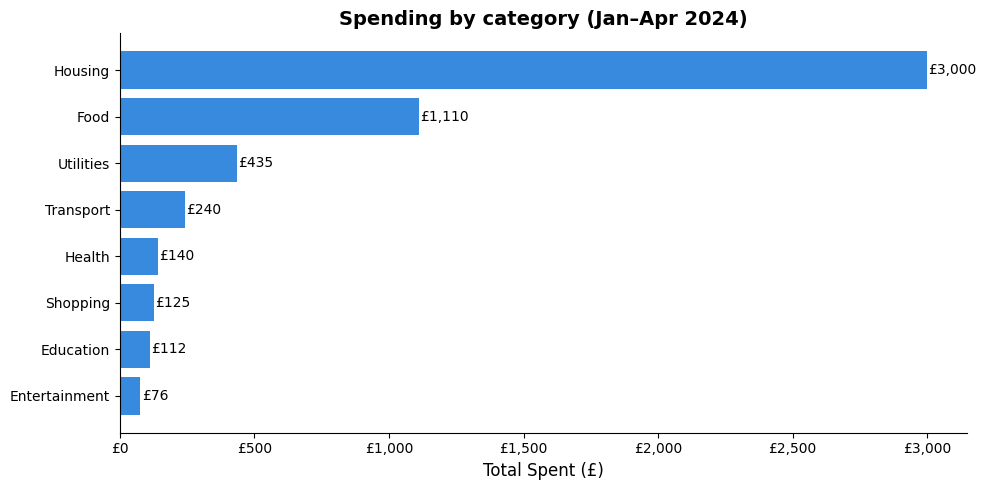

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Chart 1: Spending by category
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(category_totals['Category'], category_totals['Total Spent (£)'],
               color='#378ADD', edgecolor='none')

ax.set_xlabel('Total Spent (£)', fontsize=12)
ax.set_title('Spending by category (Jan–Apr 2024)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.invert_yaxis()
ax.spines[['top', 'right']].set_visible(False)

# Add value labels to the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2,
            f'£{width:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('spending_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

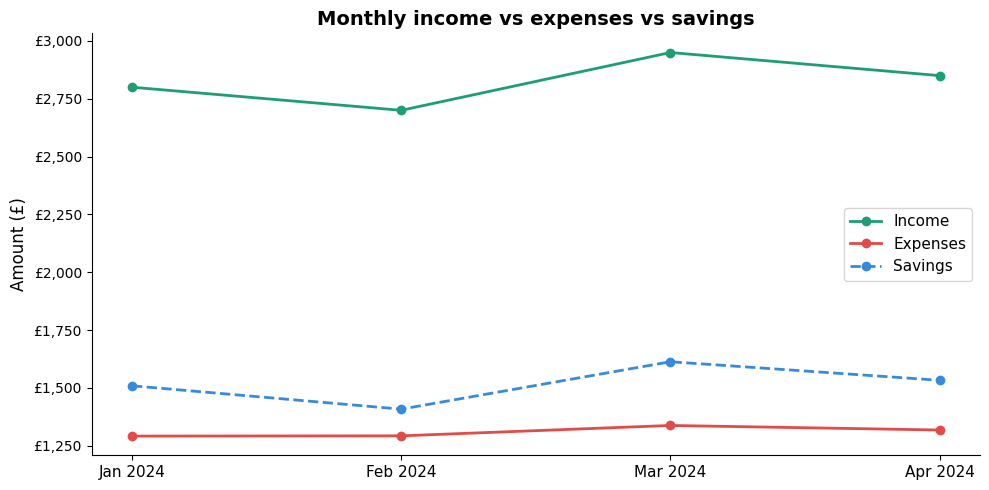

Chart saved!


In [19]:
# --- Chart 2: Monthly income vs expenses vs savings ---
months = list(monthly.index)
x = range(len(months))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, monthly['Income'],   marker='o', label='Income',   color='#1D9E75', linewidth=2)
ax.plot(x, monthly['Expenses'], marker='o', label='Expenses', color='#E24B4A', linewidth=2)
ax.plot(x, monthly['Savings'],  marker='o', label='Savings',  color='#378ADD', linewidth=2, linestyle='--')

ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=11)
ax.set_ylabel('Amount (£)', fontsize=12)
ax.set_title('Monthly income vs expenses vs savings', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'£{y:,.0f}'))
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [20]:
from google.colab import files
files.download('spending_by_category.png')
files.download('monthly_trends.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Based on the analysis:

1. **Housing is the dominant expense** at £3,000 which accounts for 57% of total spending over 4 months.
2. **Savings rate averages ~52%** is well above the recommended 20% benchmark.
3. **March 2024 was the strongest month** with the highest freelance income (£450) which pushed savings to their peak.
4. **Food is the second largest category** at £1,110 which is a potential area to optimise.